# ICE and PG Performance Measure

In [1]:
from ONNX_Predict.LSTM_onnx import LSTM_onnx 
from ONNX_Predict.Scaler_onnx import Scaler_onnx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import tensorflow as tf

2026-02-13 13:48:48.692769: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 13:48:48.711210: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-13 13:48:48.711225: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-13 13:48:48.711888: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-13 13:48:48.715609: I tensorflow/core/platform/cpu_feature_guar

## Reading Models and Scalers and Data

### Paths

In [ ]:
ICE_folder = os.path.join(
    os.pardir, "controller_for_ICE_PG", "SHARE", "CTTC_models", "ONNX", "ICE"
)
PG_folder = os.path.join(
    os.pardir, "controller_for_ICE_PG", "SHARE", "CTTC_models", "ONNX", "PG"
)
tf_model = "model.h5"

### Reading Input

In [ ]:
csvPath = os.path.join(os.pardir, "internal_lstm_models", "Test_Cycles", "WLTC.csv")

df = pd.read_csv(csvPath, sep=";")

# Select relevant columns for ICE
ICEinput = df[["ICE_Speed_rpm", "fuel_mg", "T_amb_K", "p_amb_bar"]].copy()

# Select relevant columns for PG (Torque will be added from prediction)
PGinput = df[["ICE_Speed_rpm", "EM2_Torque_Nm", "Brake_perc"]].copy() # here notice that torque is missing since it must be predicted by ICE first

print(f"Loaded DataFrame with {len(df)} rows.")

Loaded DataFrame with 3601 rows.


### Preprocessing

In [4]:
# Use the full dataset
x_all = ICEinput.to_numpy().astype('float32')
print(f"Input shape: {x_all.shape}")

Input shape: (3601, 4)


## Prediction ONNX: ICE

In [5]:
ICEscaler_in = Scaler_onnx('scaler_input.onnx', ICE_folder)
ICEscaler_out = Scaler_onnx('scaler_output.onnx', ICE_folder)
ICEscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', ICE_folder)
ICE = LSTM_onnx('ICE_onnx.onnx', ICE_folder, tf_model)

2026-02-13 13:48:53.658439538 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706330, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-13 13:48:53.673838139 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706332, index: 4, mask: {5, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-13 13:48:53.673883123 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706331, index: 3, mask: {4, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-13 13:48:53.675135525 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706334, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the n

In [6]:
# Preparing Initial AUX Data
Torque = 0
NO_ini = 0
NO2_ini = 0
CO_ini = 0
CO2_ini = 0
y_initial_ice = np.array([[Torque, NO_ini, NO2_ini, CO_ini, CO2_ini]], dtype='float32')
y_scaled_initial_ice = ICEscaler_out.transform(y_initial_ice)[0].reshape((1,1,5))

**IMPORTANT**

Note that 3 scalers are loaded into memory instead of 2.

This is because onnx models can only perform the transformation in one direction. Requiring an inverse transformation for prediction, `scaler_inverse_output.onnx` had to be generated for each model

In [7]:
y_predict_scaled_list = []
ICE.reset_states()

print("Running ICE ONNX Inference Loop...")
# Loop over all inputs
for i in range(len(x_all)):
    # 1. Scale Input (Single Step)
    x_step = x_all[i].reshape(1, -1)
    x_scaled = ICEscaler_in.transform(x_step)[0].reshape(1, 1, 4)
    
    # 2. Predict
    # Note: y_scaled_initial_ice is constant/static (Aux input)
    y_predict_scaled = ICE([x_scaled, y_scaled_initial_ice])
    
    # 3. Store
    y_predict_scaled_list.append(y_predict_scaled[0][0][0])
    
    # 4. Update AUX
    y_scaled_initial_ice = y_predict_scaled[0]

print("ICE Inference Complete.")
y_predict_scaled_list = np.array(y_predict_scaled_list)

Running ICE ONNX Inference Loop...
ICE Inference Complete.


### Performance

In [8]:
%%timeit
ICE([x_scaled, y_scaled_initial_ice])

30.3 μs ± 24 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Results

In [9]:
plot_data_ice_onnx = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data_ice_onnx.shape

In [10]:
y_pred_list = []

for pred in range(preds):
    y_pred = ICEscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])
    
plot_data_ice_onnx = np.array(y_pred_list)

In [11]:
labels = ['Torque', 'NO', 'NO2', 'CO', 'CO2']

df_predictions_onnx = pd.DataFrame(data=plot_data_ice_onnx, columns=labels)
df_predictions_onnx

,Torque,NO,NO2,CO,CO2
0,-13.241338,0.002255,1.967410e-05,0.000616,-0.000889
1,2.681764,0.001062,5.232610e-06,-0.000754,0.010424
2,-5.853482,-0.001819,-2.343051e-05,0.001763,0.056763
3,-9.046647,-0.001523,5.226174e-07,0.005159,0.065955
4,-10.089470,-0.001129,1.774917e-05,0.007912,0.068763
...,...,...,...,...,...
3596,60.370007,0.000222,1.370905e-06,0.000074,0.093743
3597,60.118336,0.000235,1.437841e-06,0.000076,0.093457
3598,59.351208,0.000246,1.483410e-06,0.000078,0.093958
3599,58.785194,0.000253,1.525116e-06,0.000079,0.094697


In [12]:
df_predictions_onnx.describe().loc[['mean', 'std']]

,Torque,NO,NO2,CO,CO2
mean,49.960667,0.000345,-0.000002,0.000092,0.143380
std,68.118927,0.000907,0.000004,0.000471,0.025409


**IMPORTANT:**

It can be observed how the first torque prediction produces a negative result --> `-30.66 Nm`

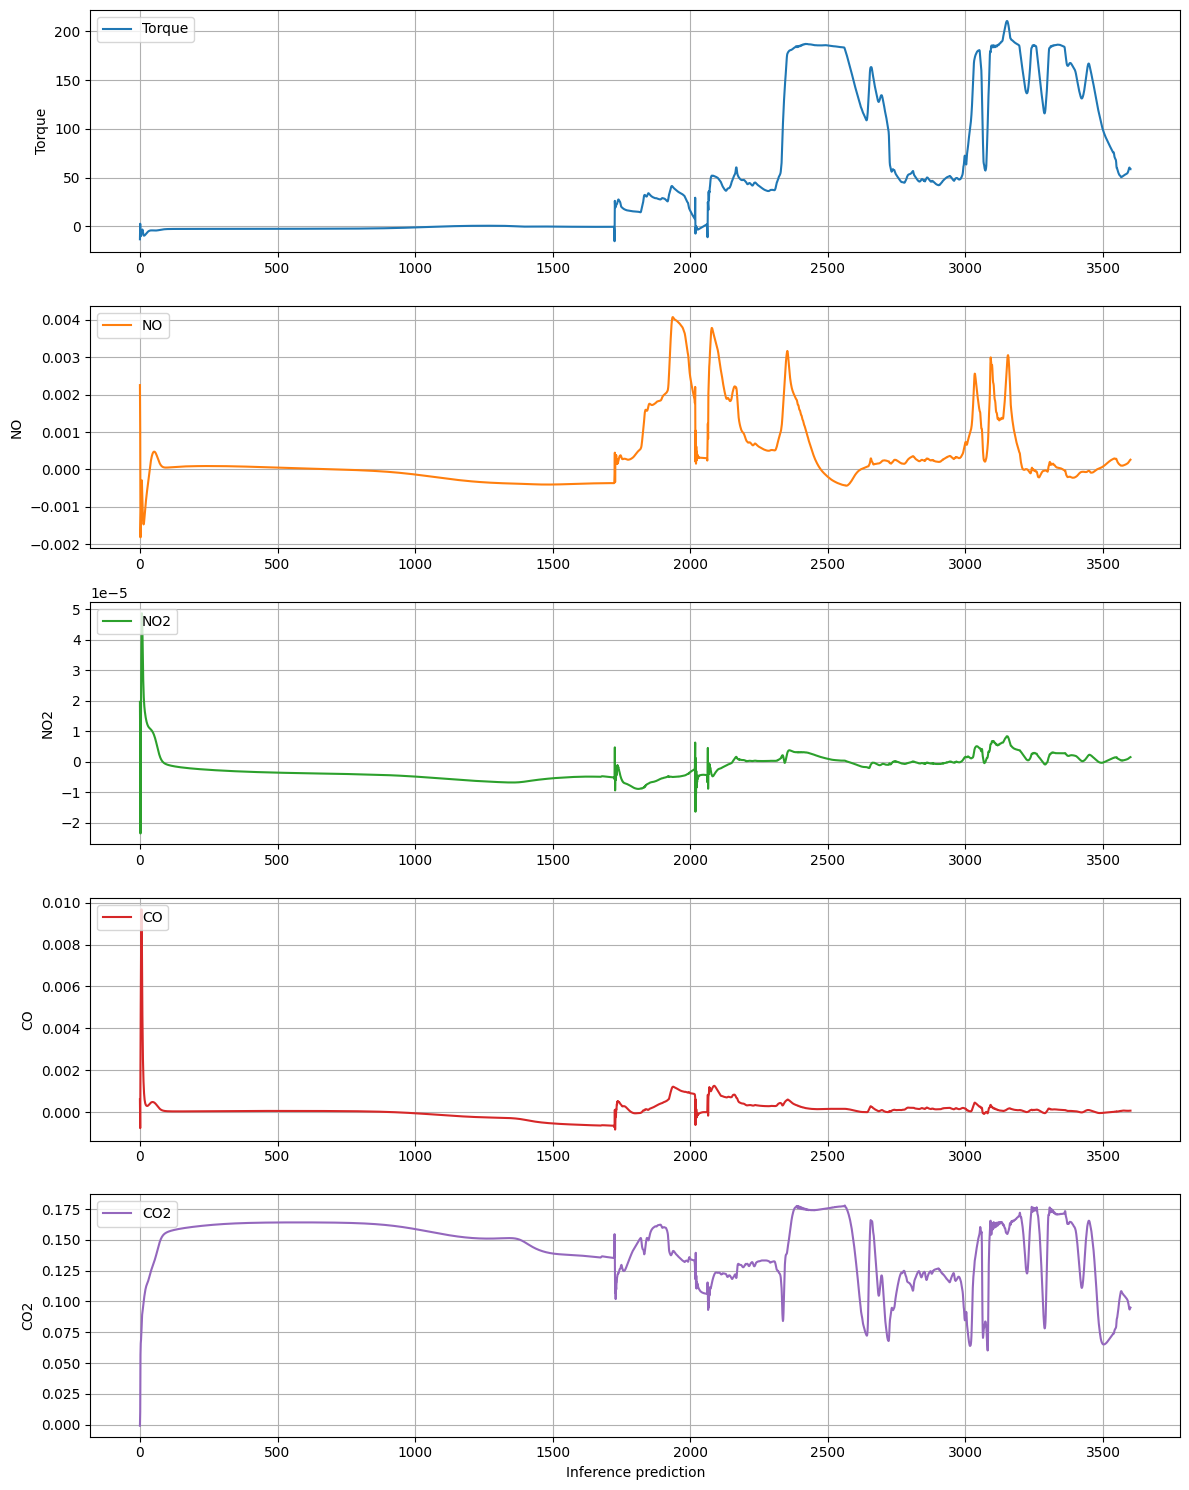

In [13]:
fig, axs = plt.subplots(plot_vars, 1, figsize=(12, 3*plot_vars), sharex=False)

for var in range(plot_vars):
    axs[var].plot(plot_data_ice_onnx[:,var], label=labels[var], c=f'C{var}')
    axs[var].set_ylabel(labels[var])
    axs[var].legend(loc='upper left')
    axs[var].grid(True)

axs[-1].set_xlabel('Inference prediction')
plt.tight_layout()
plt.show()

---
## Prediction TF: ICE

In [14]:
ICE_tf_path = os.path.join(ICE_folder, tf_model)
print(f"Loading TF bucket from: {ICE_tf_path}")
ICE_tf = tf.keras.models.load_model(ICE_tf_path)

Loading TF bucket from: CTTC_models/ONNX/ICE/model.h5


### Performance

In [15]:
%%timeit
ICE_tf([x_scaled, y_scaled_initial_ice])

13.9 ms ± 11.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
ICE_tf.reset_states()
y_predict_scaled_tf_list = []

print("Running ICE TF Inference Loop...")
for i in range(len(x_all)):
    # 1. Scale Input
    x_step = x_all[i].reshape(1, -1)
    x_scaled = ICEscaler_in.transform(x_step)[0].reshape(1, 1, 4)
    
    # 2. Predict (Tensorflow)
    # TF model expects list of tensors/arrays
    pred = ICE_tf([x_scaled, y_scaled_initial_ice])
    y_predict_scaled_tf_list.append(pred.numpy()[0][0].reshape(-1))
    
    # 3. Update AUX
    y_scaled_initial_ice = pred

print("ICE TF Inference Complete.")

Running ICE TF Inference Loop...
ICE TF Inference Complete.


### Results

In [17]:
y_pred_tf_list = []

for pred in range(len(y_predict_scaled_tf_list)):
    y_pred = ICEscaler_inv_out.transform(y_predict_scaled_tf_list[pred].reshape(1, -1))
    y_pred_tf_list.append(y_pred[0][0])

TODO Check on which results are compared: must be in the real scale domain instead of minmax

In [18]:
# Create DataFrame for comparison
onnx_results = np.array(y_predict_scaled_list) # From previous ONNX run
tf_results = np.array(y_predict_scaled_tf_list)

diff = np.abs(onnx_results - tf_results)

# Calculate metrics
max_diff = np.max(diff, axis=0) # Max difference per variable
avg_diff = np.mean(diff, axis=0) # MAE per variable
rmse = np.sqrt(np.mean((onnx_results - tf_results)**2, axis=0)) # RMSE per variable

overall_max = np.max(diff)
overall_mae = np.mean(diff)
overall_rmse = np.sqrt(np.mean((onnx_results - tf_results)**2))

print(f"Overall Max Absolute Difference: {overall_max}")
print(f"Overall Mean Absolute Difference (MAE): {overall_mae}")
print(f"Overall Root Mean Squared Error (RMSE): {overall_rmse}")
print("-" * 30)

# Create a summary dataframe for per-variable metrics
metrics_df = pd.DataFrame({
    'Variable': labels,
    'Max Difference': max_diff,
    'MAE': avg_diff,
    'RMSE': rmse
})
print("Per-variable metrics:")
print(metrics_df)

Overall Max Absolute Difference: 0.02959418296813965
Overall Mean Absolute Difference (MAE): 0.0005313439760357141
Overall Root Mean Squared Error (RMSE): 0.0017472007311880589
------------------------------
Per-variable metrics:
  Variable  Max Difference       MAE      RMSE
0   Torque        0.020625  0.000360  0.000786
1       NO        0.013956  0.000238  0.000613
2      NO2        0.009874  0.000080  0.000234
3       CO        0.012556  0.000159  0.000534
4      CO2        0.029594  0.001820  0.003732


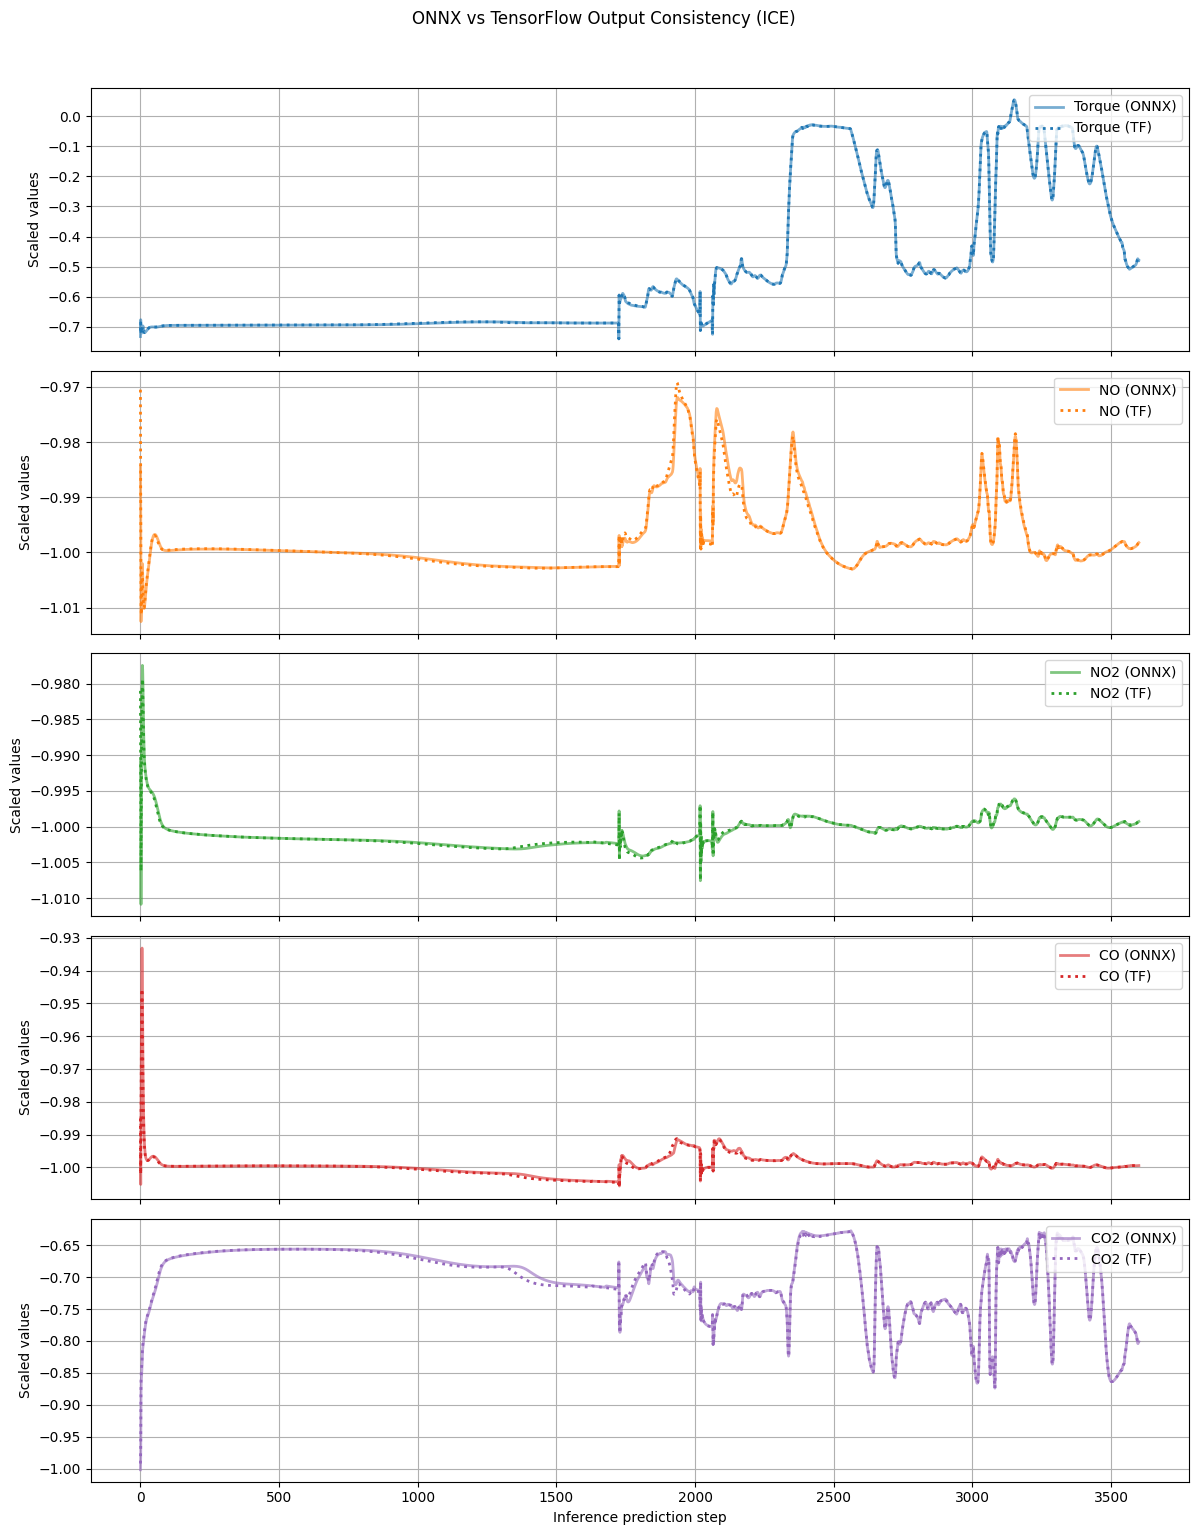

In [19]:
# Plotting Comparison
fig, axs = plt.subplots(plot_vars, 1, figsize=(12, 3*plot_vars), sharex=True)

for var in range(plot_vars):
    color = f'C{var}'
    axs[var].plot(onnx_results[:, var], label=f'{labels[var]} (ONNX)', linestyle='-', color=color, alpha=0.6, linewidth=2)
    axs[var].plot(tf_results[:, var], label=f'{labels[var]} (TF)', linestyle=':', color=color, alpha=1.0, linewidth=2)
    axs[var].set_ylabel('Scaled values')
    axs[var].legend(loc='upper right')
    axs[var].grid(True)

axs[-1].set_xlabel('Inference prediction step')
plt.suptitle('ONNX vs TensorFlow Output Consistency (ICE)', y=1.02)
plt.tight_layout()
plt.show()

---
## Prediction ONNX: PG

In [20]:
# Prepare PG inputs using the PREDICTED Torque from ICE
# y_pred is the DataFrame of descaled ICE results
torque_pred = df_predictions_onnx['Torque'].values


pg_speed = PGinput['ICE_Speed_rpm'].values
pg_em2 = PGinput['EM2_Torque_Nm'].values
pg_brake = PGinput['Brake_perc'].values

# Stack inputs
x_pg_all = np.column_stack([pg_speed, pg_em2, torque_pred, pg_brake]).astype('float32')
print(f"PG Input Shape: {x_pg_all.shape}")

PG Input Shape: (3601, 4)


In [21]:
PGscaler_in = Scaler_onnx('scaler_input.onnx', PG_folder)
PGscaler_out = Scaler_onnx('scaler_output.onnx', PG_folder)
PGscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', PG_folder)
PG = LSTM_onnx('PG_onnx.onnx', PG_folder, tf_model)

2026-02-13 13:52:27.614563582 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706532, index: 2, mask: {3, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-13 13:52:27.623870019 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706540, index: 10, mask: {11, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-13 13:52:27.624324001 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706536, index: 6, mask: {7, }, error code: 22 error msg: Invalid argument. Specify the number of threads explicitly so the affinity is not set.
2026-02-13 13:52:27.625335457 [E:onnxruntime:Default, env.cc:226 ThreadMain] pthread_setaffinity_np failed for thread: 3706539, index: 9, mask: {10, }, error code: 22 error msg: Invalid argument. Specify th

In [22]:
SOC_ini = 0.7
velocity_ini = 0

y_initial_pg = np.array([[velocity_ini, SOC_ini]], dtype='float32')
y_scaled_initial_pg = PGscaler_out.transform(y_initial_pg)[0].reshape((1,1,2))

In [23]:
y_predict_scaled_list = [] # Reset for PG
PG.reset_states()

print("Running PG ONNX Inference Loop...")
for i in range(len(x_pg_all)):
    # 1. Scale Input
    x_step = x_pg_all[i].reshape(1, -1)
    x_scaled = PGscaler_in.transform(x_step)[0].reshape(1, 1, 4)
    
    # 2. Predict
    y_predict_scaled = PG([x_scaled, y_scaled_initial_pg])
    
    # 3. Store
    y_predict_scaled_list.append(y_predict_scaled[0][0][0])
    
    # 4. Update AUX
    y_scaled_initial_pg = y_predict_scaled[0]
    
print("PG ONNX Inference Complete.")
y_predict_scaled_list = np.array(y_predict_scaled_list)

Running PG ONNX Inference Loop...
PG ONNX Inference Complete.


### Performance

In [24]:
%%timeit
PG([x_scaled, y_scaled_initial_pg])

106 μs ± 20.3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Results

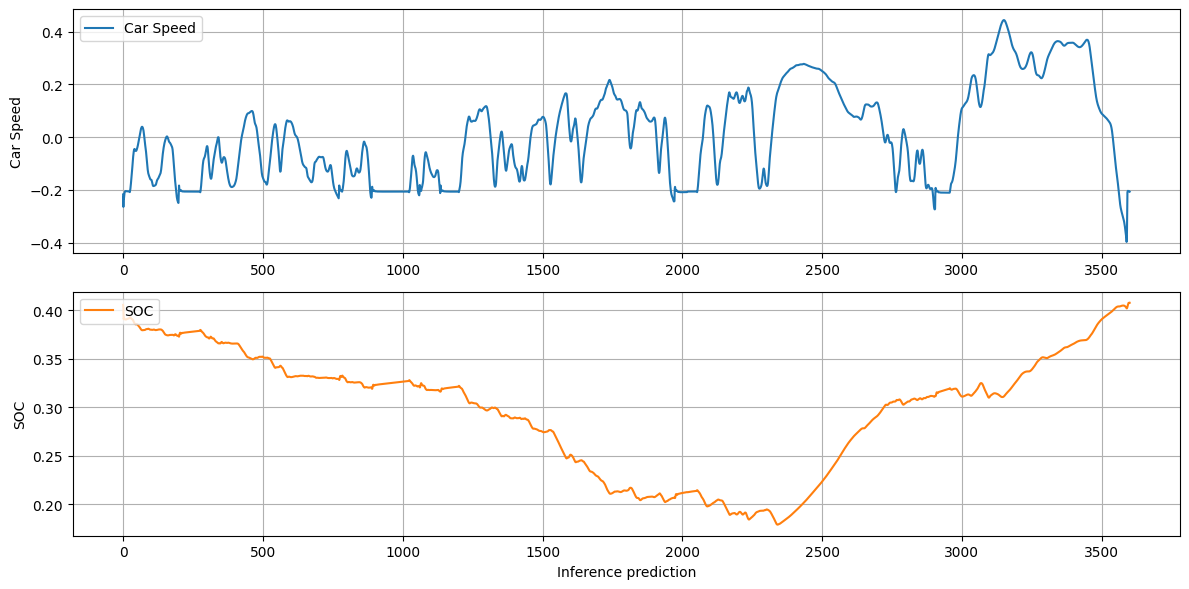

In [25]:
plot_data_pg_onnx = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data_pg_onnx.shape

labels = ['Car Speed', 'SOC']

fig, axs = plt.subplots(plot_vars, 1, figsize=(12, 3*plot_vars), sharex=False)

for var in range(plot_vars):
    axs[var].plot(plot_data_pg_onnx[:,var], label=labels[var], c=f'C{var}')
    axs[var].set_ylabel(labels[var])
    axs[var].legend(loc='upper left')
    axs[var].grid(True)

axs[-1].set_xlabel('Inference prediction')
plt.tight_layout()
plt.show()

In [26]:
y_pred_list = []

for pred in range(preds):
    y_pred = PGscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])
    
plot_data_pg_onnx_real_values = np.array(y_pred_list)

In [27]:
y_pred = pd.DataFrame(data=plot_data_pg_onnx_real_values, columns=labels)
y_pred

,Car Speed,SOC
0,-2.160207,0.702695
1,-9.980642,0.701268
2,-3.779951,0.695267
3,-4.782743,0.695973
4,-2.668868,0.695460
...,...,...
3596,-0.116276,0.703684
3597,-0.005055,0.703728
3598,-0.017671,0.703668
3599,-0.182107,0.703660


In [28]:
y_pred.describe().loc[['mean', 'std', "max"]]

,Car Speed,SOC
mean,35.538506,0.648802
std,29.434689,0.031253
max,107.587677,0.703741


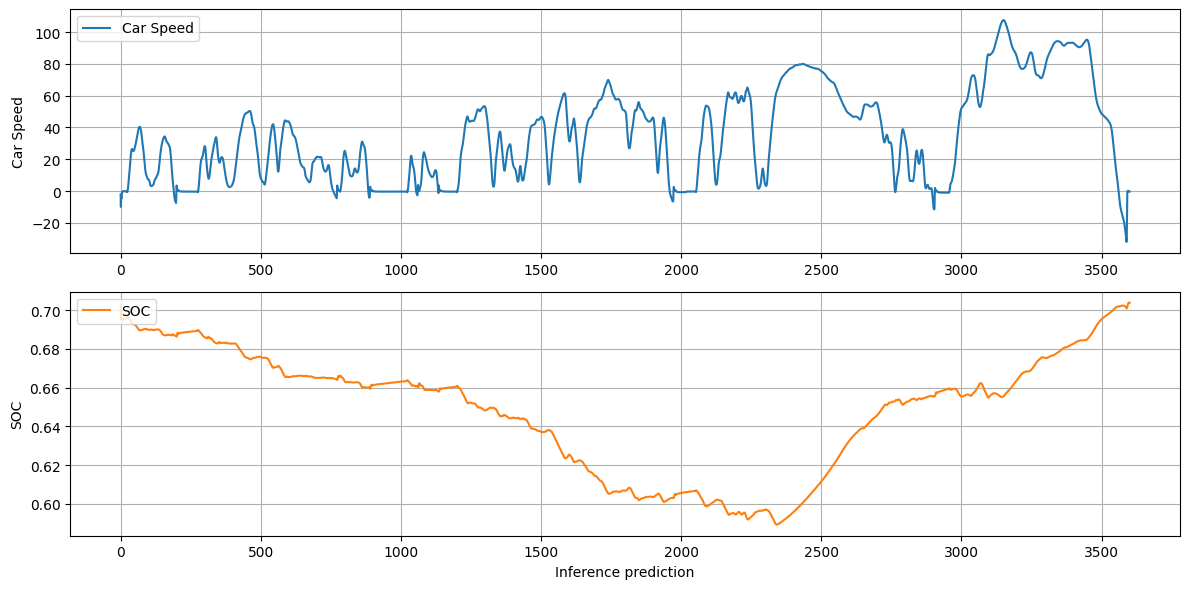

In [29]:
plot_data_pg_onnx = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data_pg_onnx.shape

labels = ['Car Speed', 'SOC']

fig, axs = plt.subplots(plot_vars, 1, figsize=(12, 3*plot_vars), sharex=False)

for var in range(plot_vars):
    axs[var].plot(plot_data_pg_onnx_real_values[:,var], label=labels[var], c=f'C{var}')
    axs[var].set_ylabel(labels[var])
    axs[var].legend(loc='upper left')
    axs[var].grid(True)

axs[-1].set_xlabel('Inference prediction')
plt.tight_layout()
plt.show()

---
## Prediction TF: PG


In [30]:
PG_tf_path = os.path.join(PG_folder, tf_model)
PG_tf = tf.keras.models.load_model(PG_tf_path)

### Performance

In [31]:
%%timeit
PG_tf([x_scaled, y_scaled_initial_pg])

14.6 ms ± 18.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [32]:
PG_tf.reset_states()
y_predict_scaled_pg_tf_list = []

print("Running PG TF Inference Loop...")
for i in range(len(x_pg_all)):
    # 1. Scale Input
    x_step = x_pg_all[i].reshape(1, -1)
    x_scaled = PGscaler_in.transform(x_step)[0].reshape(1, 1, 4)
    
    # 2. Predict
    pred = PG_tf([x_scaled, y_scaled_initial_pg])
    y_predict_scaled_pg_tf_list.append(pred.numpy()[0][0].reshape(-1))
    
    # 3. Update AUX
    y_scaled_initial_pg = pred
    
print("PG TF Inference Complete.")

Running PG TF Inference Loop...
PG TF Inference Complete.


### Results

In [33]:
y_pred_tf_list = []

for pred in range(len(y_predict_scaled_pg_tf_list)):
    y_pred = PGscaler_inv_out.transform(y_predict_scaled_pg_tf_list[pred].reshape(1, -1))
    y_pred_tf_list.append(y_pred[0][0])

tf_plot_data_real = np.array(y_pred_tf_list)
onnx_plot_data_real = plot_data_pg_onnx_real_values # already computed in ONNX section

# Metrics Calculation for Real Units
diff_real = np.abs(onnx_plot_data_real - tf_plot_data_real)
max_diff_real = np.max(diff_real, axis=0)
mae_real = np.mean(diff_real, axis=0)
rmse_real = np.sqrt(np.mean((onnx_plot_data_real - tf_plot_data_real)**2, axis=0))

metrics_df_real = pd.DataFrame({
    'Variable': labels,
    'Max Difference': max_diff_real,
    'MAE': mae_real,
    'RMSE': rmse_real
})

print("Per-variable metrics (PG Real Units):")
print(metrics_df_real)

Per-variable metrics (PG Real Units):
    Variable  Max Difference       MAE      RMSE
0  Car Speed        0.147573  0.022924  0.029000
1        SOC        0.003560  0.003343  0.003343


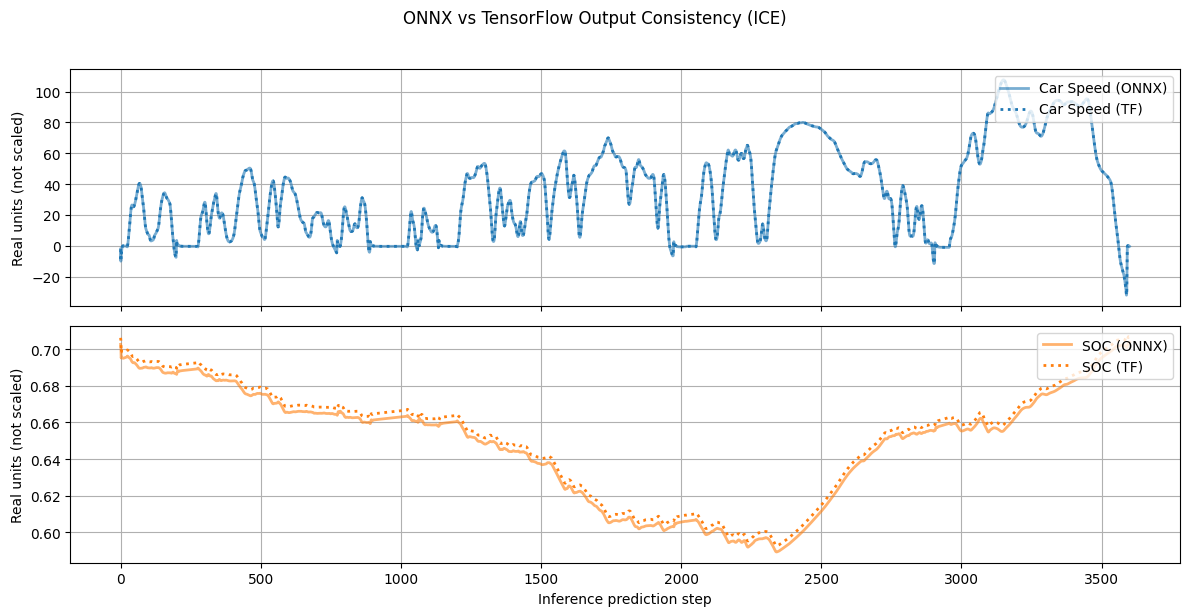

In [34]:
# Plotting Comparison
fig, axs = plt.subplots(plot_vars, 1, figsize=(12, 3*plot_vars), sharex=True)

for var in range(plot_vars):
    color = f'C{var}'
    axs[var].plot(onnx_plot_data_real[:, var], label=f'{labels[var]} (ONNX)', linestyle='-', color=color, alpha=0.6, linewidth=2)
    axs[var].plot(tf_plot_data_real[:, var], label=f'{labels[var]} (TF)', linestyle=':', color=color, alpha=1.0, linewidth=2)
    axs[var].set_ylabel("Real units (not scaled)")
    axs[var].legend(loc='upper right')
    axs[var].grid(True)

axs[-1].set_xlabel('Inference prediction step')
plt.suptitle('ONNX vs TensorFlow Output Consistency (ICE)', y=1.02)
plt.tight_layout()
plt.show()